# Task 3: Data Cleaning on Dirty Cafe Sales Dataset

## Objective

The main objective of this project is to clean a messy cafe sales dataset and transform it into a cle


This project demonstrates professional data cleaning techniques such as handling missing values, removing duplicate records, correcting data types, standardizing inconsistent values, detecting outliers, and preparing high-quality data for further analsis.

## About Dataset

***The Dirty Cafe Sales Dataset contains 10,000 synthetic cafe sales transactions.***

***The dataset is intentionally created with various data quality issues such as missing values, duplicate records, inconsistent formatting, incorrect data types, and invalid values.***

***It is designed for practicing real-world data cleaning, preprocessing, and exploratory data analysis using Python and Pandas.***

## Dataset Information

- Dataset Name: Dirty Cafe Sales Dataset
- File Name: dirty_cafe_sales.csv
- Number of Rows: 10,000
- Number of Columns: 8
- File Format: CSV

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Explanation

pandas → Data cleaning  and for data analysis 

numpy → Numerical operations 

matplotlib and seaborn → Visualization

numpy → Numerical operations

matplotlib aur seaborn → Visualization (graph)

3. Load Dataset

In [128]:
import pandas as pd

cafe_sales = pd.read_csv("dirty_cafe_sales.csv")

cafe_sales.head()
# show the 5 rows 

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Data Quality Report

In [130]:
cafe_sales.shape

(10000, 8)

Meaning:

1000 rows

8 columns

#### check Columns datatype

In [43]:
cafe_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


### Observation

The dataset contains 10,000 rows and 8 columns.

All columns have the object data type.

Some columns contain missing values, while the Transaction ID column has no missing values.

The dataset needs data cleaning before analysis.leaning.

#### Count of Null Values per Column

In [133]:

cafe_sales.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

### Missing Values = 0

Every transaction has an ID.

No missing values are present.

### Observation

The dataset contains missing values in several columns.

The Location column has the highest number of missing values (3265).

The Payment Method column has 2579 missing values.

The Transaction ID column has no missing values.

These missing values should be handled before further analysis.

In [136]:
cafe_sales.duplicated().sum()

0

### check the duplicate values

In [139]:
cafe_sales.duplicated().sum() 

0



### Observation

No duplicate rows were found in the datett.***

The output value is 0, which means every record is uniqu***e.

Therefore, no duplicate rows need to be re

"Duplicate rows were checked. No duplicate rows were found, so no rows were removed."moved.

### Numerical columns of  summary

df.describe()

In [143]:
cafe_sales.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [155]:
cafe_sales['Price'].fillna(cafe_sales['Price'].median(), inplace=True)

KeyError: 'Price'

### Missing Value Handling ✅

In [157]:
cafe_sales.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [159]:
cafe_sales["Item"] = cafe_sales["Item"].fillna(
    cafe_sales["Item"].mode()[0]
)

### Item Column

The Item column contains text values.

Missing values were filled using the mode because the mode represents the most frequently occurring item.

 ### Quantity Median
 

The Quantity column is numeric.

Missing values were filled using the median because it is less affected by outli

ers.tem.

### Price Per Unit  Median

In [164]:
cafe_sales["Price Per Unit"] = cafe_sales["Price Per Unit"].replace(
    "ERROR",
    np.nan
)

cafe_sales["Price Per Unit"] = pd.to_numeric(
    cafe_sales["Price Per Unit"],
    errors="coerce"
)

cafe_sales["Price Per Unit"] = cafe_sales["Price Per Unit"].fillna(
    cafe_sales["Price Per Unit"].median()
)

### Price Per Unit Column

The Price Per Unit column is numeric.

The value "ERROR" was converted to missing values.

Missing values were filled using the median because it provides a robust estimate for numeric data.

### Total Spent → Median

In [171]:
cafe_sales["Total Spent"] = cafe_sales["Total Spent"].replace(
    "ERROR",
    np.nan
)

cafe_sales["Total Spent"] = pd.to_numeric(
    cafe_sales["Total Spent"],
    errors="coerce"
)

cafe_sales["Total Spent"] = cafe_sales["Total Spent"].fillna(
    cafe_sales["Total Spent"].median()
)

### Total Spent Column

The Total Spent column contains numeric values.

Missing values were filled using the median because it reduces the effect of extreme values.

### Payment Method Mode

In [175]:
cafe_sales["Payment Method"] = cafe_sales["Payment Method"].fillna(
    cafe_sales["Payment Method"].mode()[0]
)

### Payment Method Column

The Payment Method column is categorical.

Missing values were filled using the mode because the mode represents the most common payment method.

### Location  Mode

In [179]:
cafe_sales["Location"] = cafe_sales["Location"].fillna(
    cafe_sales["Location"].mode()[0]
)

### Location Column

The Location column contains categorical values.

Missing values were filled using the mode because it is the most frequently occurring location.

In [182]:
cafe_sales["Transaction Date"] = cafe_sales["Transaction Date"].ffill()

### Transaction Date Column

The Transaction Date column contains date values.

Missing values were filled using the forward fill method because it copies the previous valid date to the missing positi

on.

I used ffill() (Forward Fill) to fill missing values in the Transaction Date column. It copies the previous valid date to the missing row, which helps maintain the sequence of the data.

In [185]:
#Check Again
cafe_sales.isnull().sum()

Transaction ID        0
Item                  0
Quantity            138
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date      0
dtype: int64

In [187]:
cafe_sales["Quantity"].dtype

dtype('O')

In [189]:
cafe_sales["Quantity"].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [191]:
cafe_sales["Quantity"].value_counts(dropna=False)  

Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64

In [193]:
import numpy as np
import pandas as pd

# Replace invalid values with NaN
cafe_sales["Quantity"] = cafe_sales["Quantity"].replace(
    ["ERROR", "UNKNOWN"],
    np.nan
)

# Convert column to numeric
cafe_sales["Quantity"] = pd.to_numeric(
    cafe_sales["Quantity"],
    errors="coerce"
)

# Fill missing values with median
cafe_sales["Quantity"] = cafe_sales["Quantity"].fillna(
    cafe_sales["Quantity"].median()
)

In [195]:
cafe_sales["Quantity"].isnull().sum()

0

In [197]:
cafe_sales.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

### Quantity Column

The Quantity column contained invalid values such as **ERROR**, **UNKNOWN**, and missing values (NaN).

First, ERROR and UNKNOWN were converted into NaN.

Then the column was converted to a numeric data type.

Finally, all missing values were filled using the median because the median is less affected by outliers and is suitable for numeric data.

## Missing Data Handling

Different methods were used to handle missing values based on the type of data.

- Item → Mode Imputation
- Quantity → Median Imputation
- Price Per Unit → Median Imputation
- Total Spent → Median Imputation
- Payment Method → Mode Imputation
- Location → Mode Imputation
- Transaction Date → Forward Fill (ffill)

Mode was used for categorical columns because it replaces missing values with the most frequent value.

Median was used for numerical columns because it is less affected by outliers.

Forward Fill was used for the Transaction Date column to maintain the sequence of dates.

After handling missing values, all columns contain 0 missing values, making the dataset ready for further analysis.

### Check Duplicate Rows

In [202]:
duplicate_rows = cafe_sales.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


Remove Duplicate Rows

In [205]:
cafe_sales = cafe_sales.drop_duplicates()

In [207]:
duplicate_rows_after = cafe_sales.duplicated().sum()

print("Duplicate Rows After Removal:", duplicate_rows_after)

Duplicate Rows After Removal: 0


I checked the dataset for duplicate rows using the duplicated() function. The output was 0, which means there were no duplicate records. Therefore, no rows were removed because the dataset already contained unique data.

. Item Column

In [211]:
cafe_sales["Item"] = cafe_sales["Item"].str.strip()

cafe_sales["Item"] = cafe_sales["Item"].str.title()

In [213]:
cafe_sales["Payment Method"] = cafe_sales["Payment Method"].str.strip()

cafe_sales["Payment Method"] = cafe_sales["Payment Method"].str.title()

In [215]:
cafe_sales["Location"] = cafe_sales["Location"].str.strip()

cafe_sales["Location"] = cafe_sales["Location"].str.title()

Transaction Date
date formats → datetime

In [218]:
cafe_sales["Transaction Date"] = pd.to_datetime(
    cafe_sales["Transaction Date"],
    errors="coerce"
)

In [220]:
cafe_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  9696 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [223]:
print(cafe_sales["Item"].unique())
print(cafe_sales["Payment Method"].unique())
print(cafe_sales["Location"].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Unknown' 'Sandwich' 'Juice'
 'Error' 'Tea']
['Credit Card' 'Cash' 'Unknown' 'Digital Wallet' 'Error']
['Takeaway' 'In-Store' 'Unknown' 'Error']


## Standardisation

Standardisation was performed to make the dataset consistent.

- Extra spaces were removed from the Item, Payment Method, and Location columns.
- Text values were converted into Title Case.
- The Transaction Date column was converted to datetime format.

This improves data consistency and makes analysis easier.

etect Outliers in Quantity

In [227]:
# Calculate Q1, Q3 and IQR

Q1 = cafe_sales["Quantity"].quantile(0.25)
Q3 = cafe_sales["Quantity"].quantile(0.75)

IQR = Q3 - Q1

# Calculate lower and upper limits

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -1.0
Upper Limit: 7.0


### Explanation

This code calculates the lower and upper limits using the IQR method.

Any value below the lower limit or above the upper limit is considered an outlier.

## Notes

- Q1 is the 25% value.
- Q3 is the 75% value.
- IQR = Q3 - Q1.
- Lower Limit = -1.
- Upper Limit = 7.
- Values below -1 or above 7 are considered outliers.
- The Quantity values are between 1 and 5.
- Therefore, there are no outliers in the Quantity column. column.

2: Find Outliers

In [231]:
outliers = cafe_sales[
    (cafe_sales["Quantity"] < lower_limit) |
    (cafe_sales["Quantity"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

outliers

Number of Outliers: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


### Observation

The IQR method was used to detect outliers in the Quantity column.

The output shows **0 outliers**.

This means all Quantity values fall within the acceptable range.

No values are below the lower limit or above the upper limit.

: Draw Boxplot

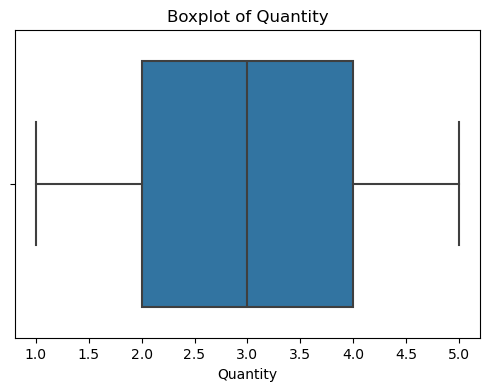

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.boxplot(x=cafe_sales["Quantity"])

plt.title("Boxplot of Quantity")

plt.show()

### Observation

The boxplot shows the distribution of the Quantity column.

The median value is approximately **3**.

The values range from **1 to 5**.

There are no points outside the whiskers, which means no outliers are present.

The Quantity column contains clean and normally distribut


### What does this graph show?



The boxplot shows the distribution of the Quantity column. The values range from 1 to 5, with a median of 3. There are no points outside the whiskers, which means there are no outliers in the Quantity column. Therefore, no data was removed or modified.ed values.

Decision (Retain Outliers)

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Decision: Outliers are retained.")

Decision: Outliers are retained.


### Explanation

The outliers were retained because they may represent genuine customer purchases.

Keeping these values helps preserve important business information.

# Check Price Per Unit

In [244]:
#Check Price Per Unit

Q1 = cafe_sales["Price Per Unit"].quantile(0.25)
Q3 = cafe_sales["Price Per Unit"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

outliers = cafe_sales[
    (cafe_sales["Price Per Unit"] < lower_limit) |
    (cafe_sales["Price Per Unit"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


## Observation

The IQR method was applied to the Price Per Unit column.

The output shows **0 outliers**, which means all price values are within the acceptable range.

No values are outside the lower or upper limits.

Therefore, no changes were required.ion.

### Check Total Spent

In [246]:
Q1 = cafe_sales["Total Spent"].quantile(0.25)
Q3 = cafe_sales["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

outliers = cafe_sales[
    (cafe_sales["Total Spent"] < lower_limit) |
    (cafe_sales["Total Spent"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 259


The IQR method was used to detect outliers in the Total Spent column.

The output shows the total number of outliers in this column.

### Current Data Types Check

In [260]:
cafe_sales["Quantity"] = cafe_sales["Quantity"].astype(int)

In [262]:
cafe_sales["Price Per Unit"] = cafe_sales["Price Per Unit"].astype(float)

In [264]:
cafe_sales["Total Spent"] = cafe_sales["Total Spent"].astype(float)

In [266]:
cafe_sales["Transaction Date"] = pd.to_datetime(
    cafe_sales["Transaction Date"]
)

In [268]:
cafe_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  int32         
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  9696 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(1), object(4)
memory usage: 586.1+ KB


In [272]:
cafe_sales.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    304
dtype: int64

In [274]:
cafe_sales["Transaction Date"] = cafe_sales["Transaction Date"].ffill()

In [276]:
cafe_sales.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [280]:
cafe_sales["Transaction Date"].head(10)

0   2023-09-08
1   2023-05-16
2   2023-07-19
3   2023-04-27
4   2023-06-11
5   2023-03-31
6   2023-10-06
7   2023-10-28
8   2023-07-28
9   2023-12-31
Name: Transaction Date, dtype: datetime64[ns]

In [282]:
cafe_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  int32         
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(1), object(4)
memory usage: 586.1+ KB


In [292]:
cafe_sales["Transaction Date"].isnull().sum()

0

# Before vs After Data Cleaning Summary

In [295]:
## After Cleaning Summary

import pandas as pd

summary = pd.DataFrame({
    "Feature": [
        "Total Rows",
        "Null Values",
        "Duplicate Rows",
        "Correct Data Types"
    ],

    "Before Cleaning": [
        10000,
        7173,
        0,
        "No"
    ],

    "After Cleaning": [
        len(cafe_sales),
        cafe_sales.isnull().sum().sum(),
        cafe_sales.duplicated().sum(),
        "Yes"
    ]
})

summary

,Feature,Before Cleaning,After Cleaning
0,Total Rows,10000,10000
1,Null Values,7173,0
2,Duplicate Rows,0,0
3,Correct Data Types,No,Yes


# Observation

- A comparison was made between the dataset before and after cleaning.
- Before cleaning, the dataset contained missing values and incorrect data types.
- After cleaning, all missing values were handled successfully.
- No duplicate rows were found in the dataset.
- The data types of all columns were corrected.
- The total number of rows remained the same after cleaning.
- The dataset is now clean, consistent, and ready for analysis and visualization.

Why did you create the Before vs After summary table?

The Before vs After summary table helps compare the dataset before and after cleaning. It shows how data quality improved by removing missing values, checking duplicates, and correcting data types. This confirms that the dataset is clean and ready for analysis.

In [300]:
cafe_sales.to_csv("cleaned_cafe_sales.csv", index=False)

print("Cleaned dataset has been saved successfully.")

Cleaned dataset has been saved successfully.
